In [147]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import yfinance as yf

# plotting
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf


In [148]:
stocks = [
    # Tech
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA",
    # Finance
    "JPM", "BAC", "WFC", "C", "GS", "MS",
    # Consumer Goods
    "KO", "PG", "PEP", "WMT", "COST", "CL",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",
    # ETF
    "SPY", "QQQ", "DIA", "IWM", "VTI"
]

# Define date range
start = "2022-01-01"
end = "2025-01-01"

# Download historical data
close_historical_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]
close_historical_df.head()

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMZN,BAC,C,CL,COP,COST,CVX,DIA,EOG,...,PEP,PG,QQQ,SLB,SPY,TSLA,VTI,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,178.270294,170.404495,41.931019,54.393021,76.912796,63.700027,540.298584,102.615845,341.583527,75.843277,...,154.084091,147.359756,392.184082,29.220688,453.210358,399.926666,230.069702,45.828430,45.858704,55.125237
2022-01-04,176.007782,167.522003,43.574474,54.815407,77.167389,66.463242,537.934021,104.482979,343.629333,79.329269,...,154.306808,147.875366,387.097290,30.639347,453.058594,383.196655,229.634140,47.653255,45.018570,57.198727
2022-01-05,171.325989,164.356995,42.839012,54.177513,77.485626,65.323425,524.291077,105.162727,340.098389,77.873283,...,154.832367,148.544815,375.205231,30.639347,444.358948,362.706665,224.653412,47.237705,45.627262,57.910122
2022-01-06,168.466003,163.253998,43.701603,55.953259,76.976440,67.775742,524.176758,106.057587,338.510437,79.470703,...,154.867981,147.296478,374.941620,31.367104,443.941406,354.899994,224.596619,48.448235,45.500450,59.272198
2022-01-07,168.632507,162.554001,44.654991,56.703213,76.776398,69.632256,511.191406,107.580559,338.435791,81.667137,...,155.063950,147.215042,370.879974,32.269886,442.186340,342.320007,223.573929,49.478081,45.934784,59.758041


From Figure 2, raw prices across the 30 stocks are highly variable and generally exhibit a strong upward trend. Thus, we applied a log transformation to stabilize the variance, make the series more stationary, and allow for better comparison across stocks.

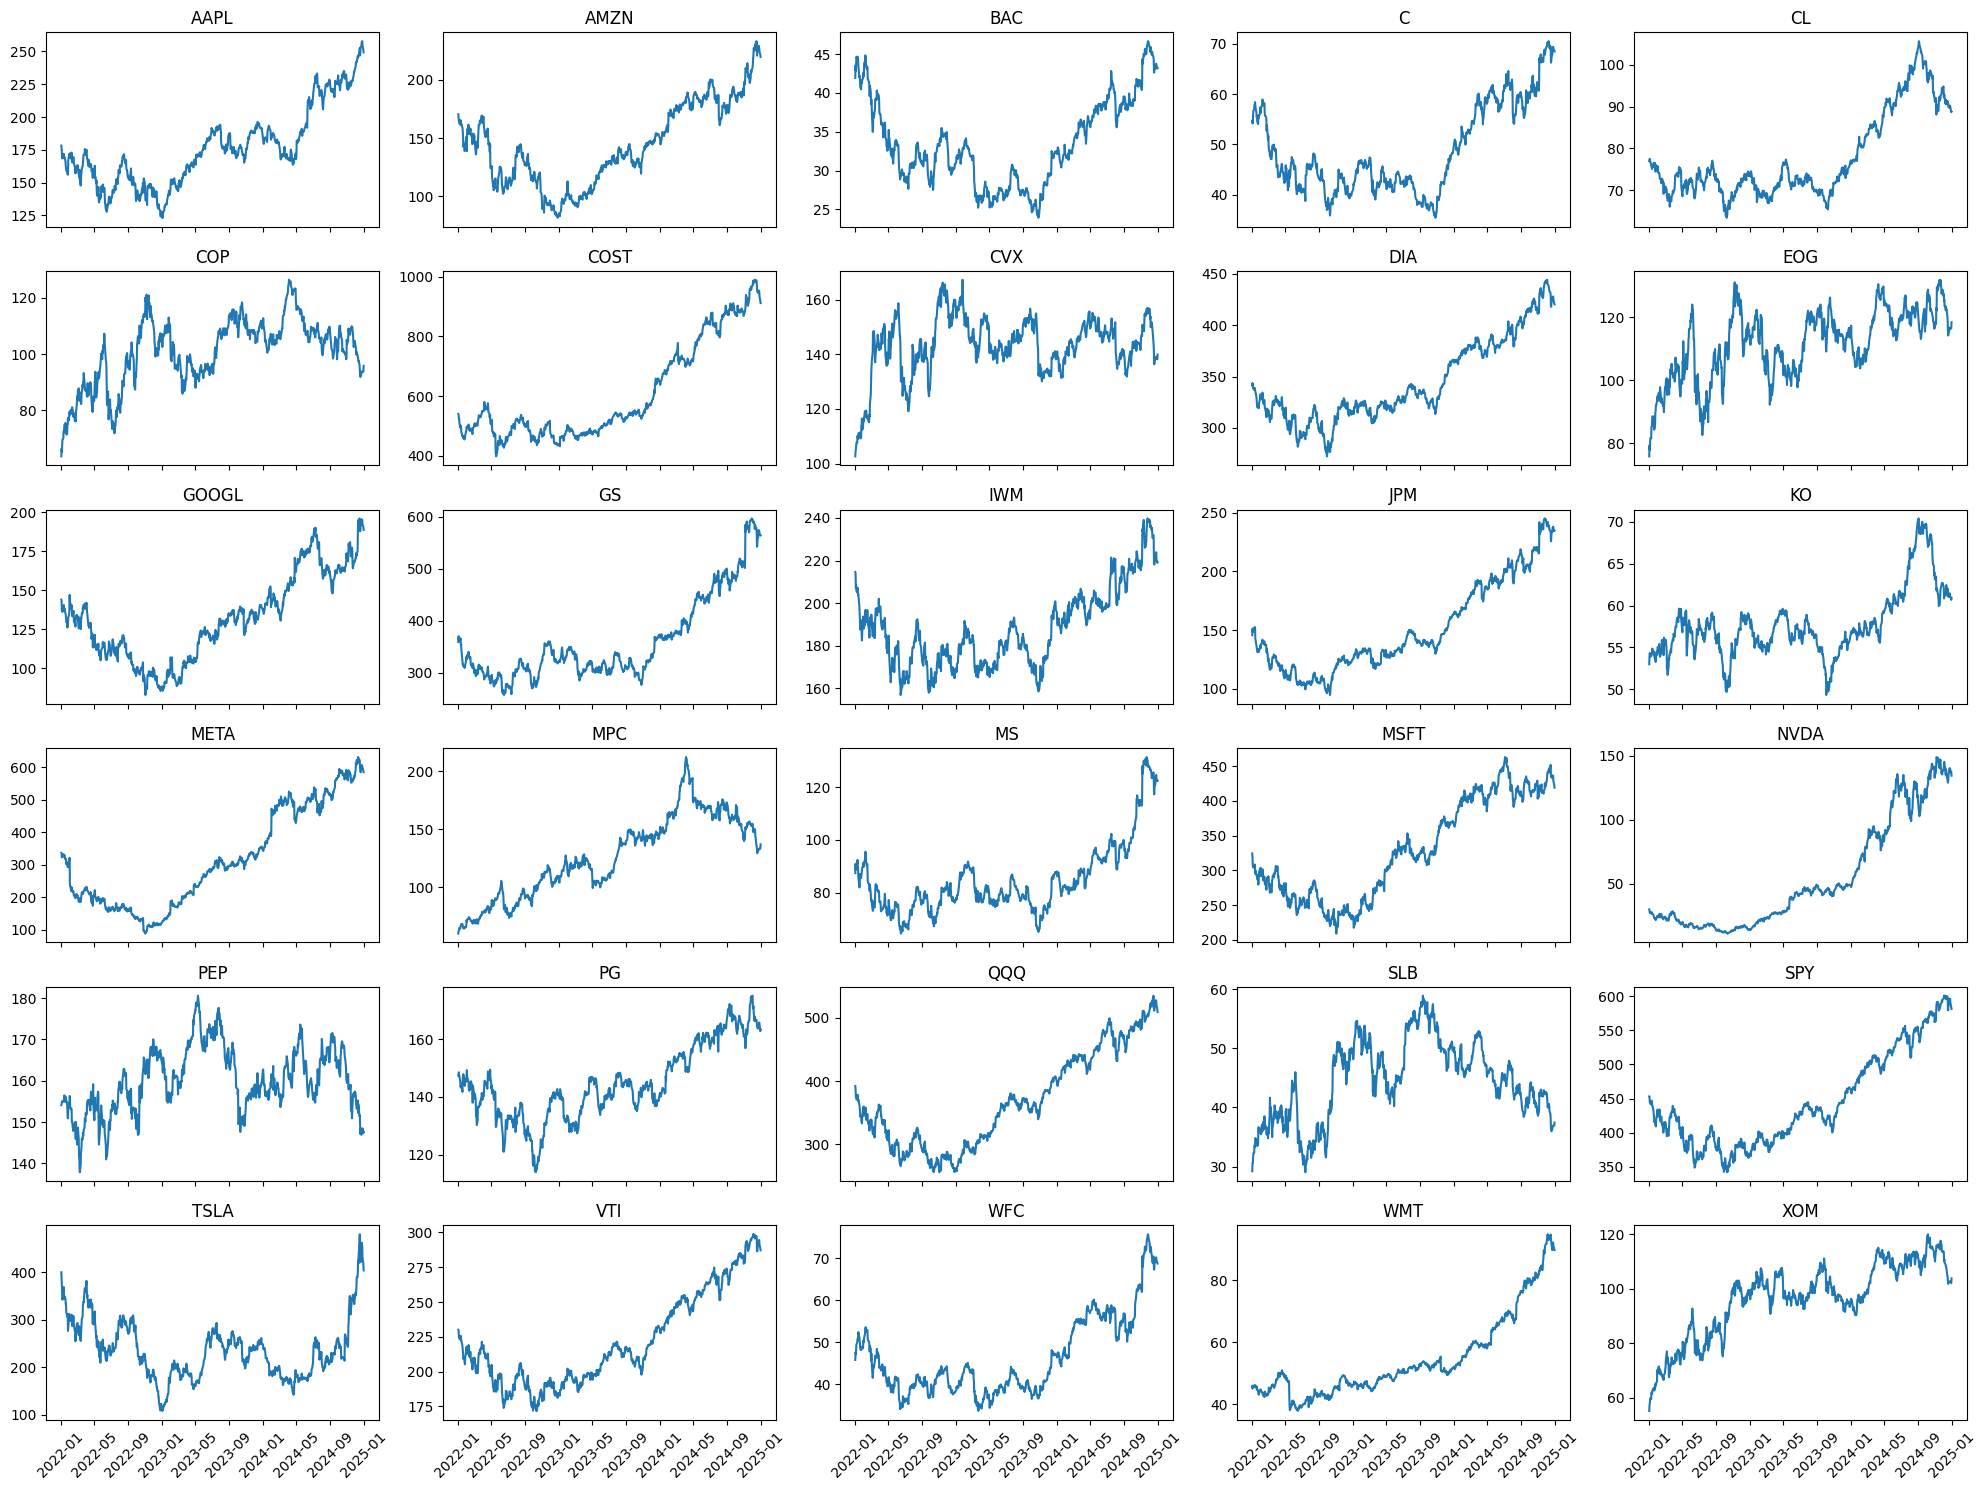

Figure 2. Prices of the 30 Stocks


In [149]:
fig, axs = plt.subplots(6, 5, figsize=(20, 15), sharex=True)

for ax, stock in zip(axs.flatten(), close_historical_df.columns):
    ax.plot(close_historical_df[stock])
    ax.set_title(stock)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Figure 2. Prices of the 30 Stocks")

# Baselines

To construct the baseline models (mean, naive, and seasonal naive) in a single figure, we first assessed whether seasonality was present across the stocks. As shown in Figure 3, there is no consistent or systematic seasonal pattern observable across the full set of assets. While a few stocks such as CVX and TSLA display indications of seasonality, these patterns are present all throughout. Given this inconsistency, we proceed by assuming a simplified seasonality of five business days for the baseline seasonal naive model.

We also implement a three-way data split consisting of training, validation, and test sets. The training and validation sets cover the period from January 2022 to January 2025, using an 80–20 split. The test set consists of the random 60-day period of observations consisting after January 2025.

Figure 3. ACF of the 30 Stocks


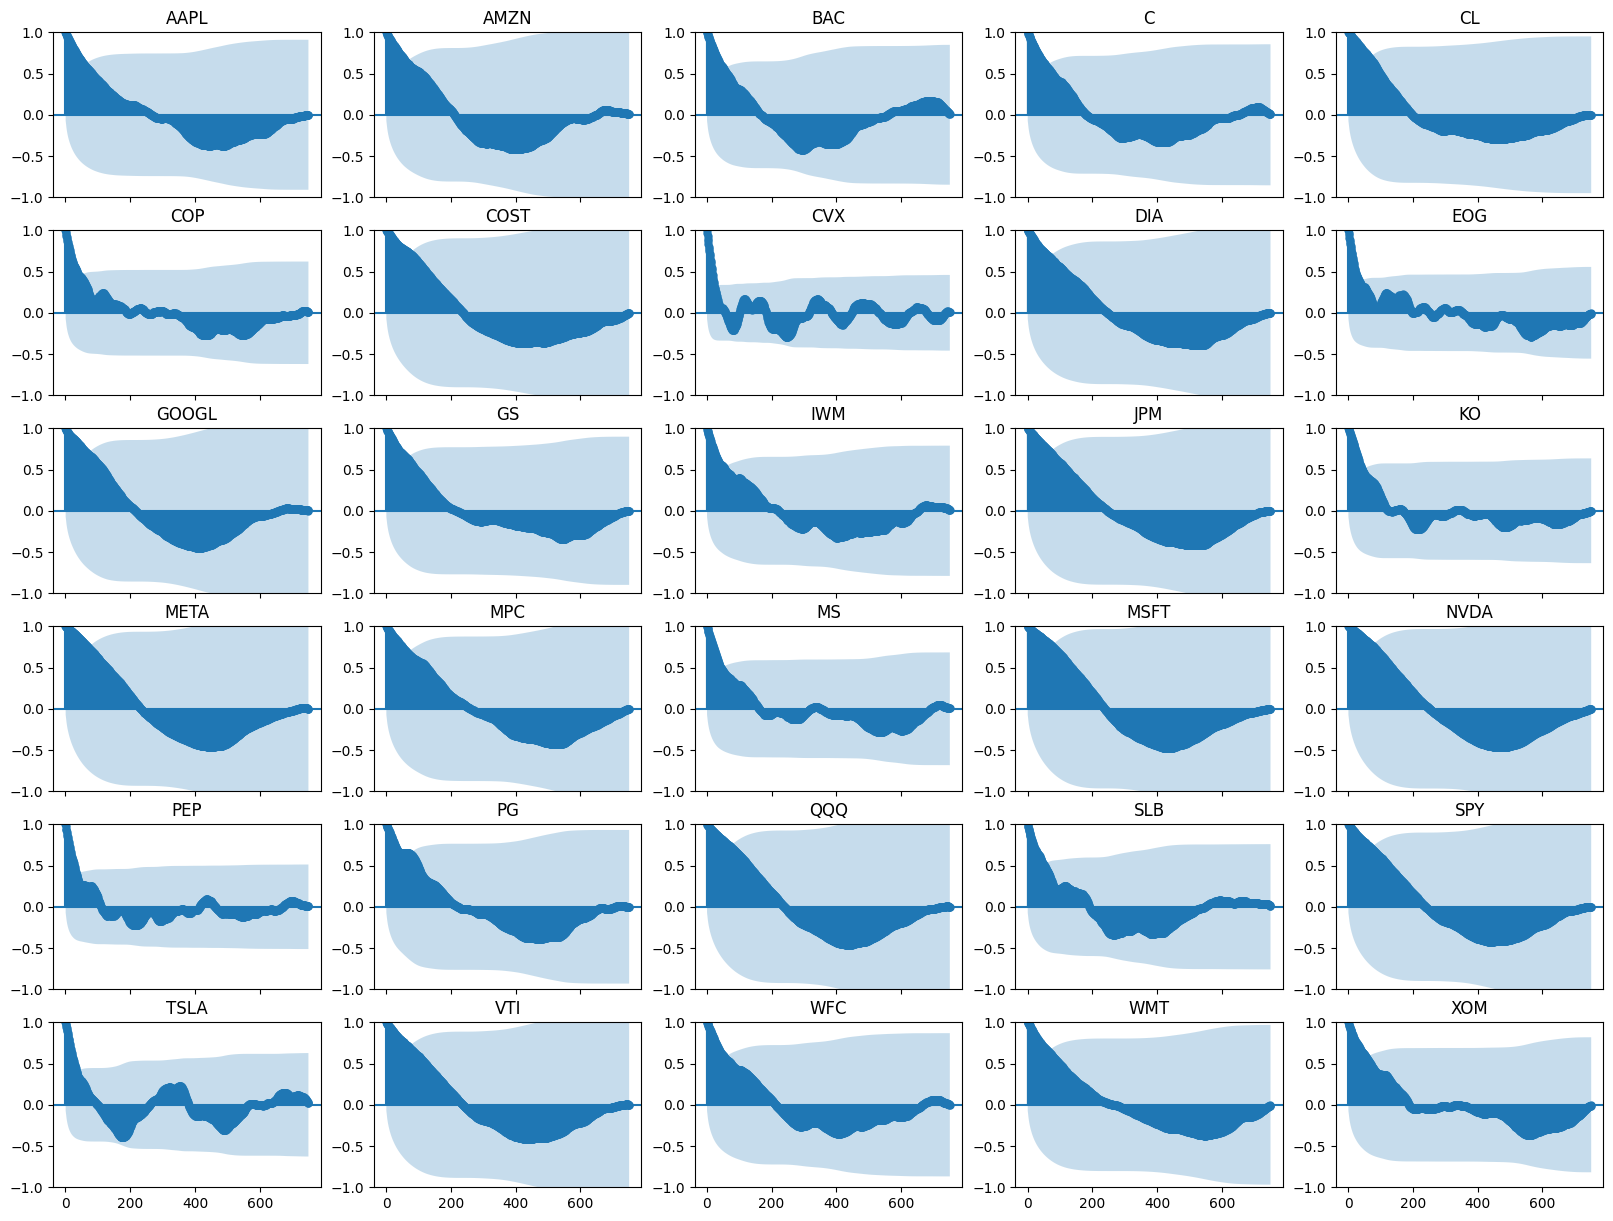

In [150]:
# Apply log
close_log_df = np.log(close_historical_df)

fig, axs = plt.subplots(6, 5, figsize=(20, 15), sharex=True)

for ax, stock in zip(axs.flatten(), close_log_df.columns):
    plot_acf(close_log_df[stock], ax=ax, lags=750, title=stock)

print("Figure 3. ACF of the 30 Stocks")

In [151]:
# Create the train and test split
val_point = int(close_log_df.shape[0] * 0.8)
num_val = close_log_df.shape[0] - val_point
train_df = close_log_df.iloc[:val_point]
val_df = close_log_df.iloc[val_point:]

def forecast_seasonal_naive(df: pd.DataFrame, m: int = 5, horizon: int = num_val) -> pd.DataFrame:
    """
    Seasonal naïve forecasting model applied column-wise to a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame where each column represents a univariate time series
        (e.g., multiple stock price series).
    m : int, optional (default=5)
        The assumed seasonality length. The model uses the last `m` observations
        of each column as the repeating seasonal pattern.
    horizon : int
        Number of future time steps to forecast.

    Returns
    -------
    pd.DataFrame
        A DataFrame containing seasonal naïve forecasts for each column of `df`.
        Each column contains `horizon` forecasts derived from the last `m` values.
    """

    forecasts = {}

    for col in df.columns:
        # Extract last seasonal cycle for this column
        last_m_vals = df[col].iloc[-m:].values.ravel()

        # Repeat the pattern to fill the forecast horizon
        repeated_vals = np.tile(last_m_vals, horizon)[:horizon]

        # Store forecasts
        forecasts[col] = repeated_vals

    return pd.DataFrame(forecasts)

In [152]:
# mean forecasts
mean_forecast = pd.DataFrame([train_df.mean().values] * num_val, 
                             index=val_df.index, 
                             columns=val_df.columns)

# naive forecasts
naive_forecast = pd.DataFrame([train_df.iloc[-1].values] * num_val,
                              index=val_df.index,
                              columns=val_df.columns)

# seasonal naive forecasts
seasonal_naive_forecast = forecast_seasonal_naive(train_df, m = 5)
seasonal_naive_forecast.index = val_df.index

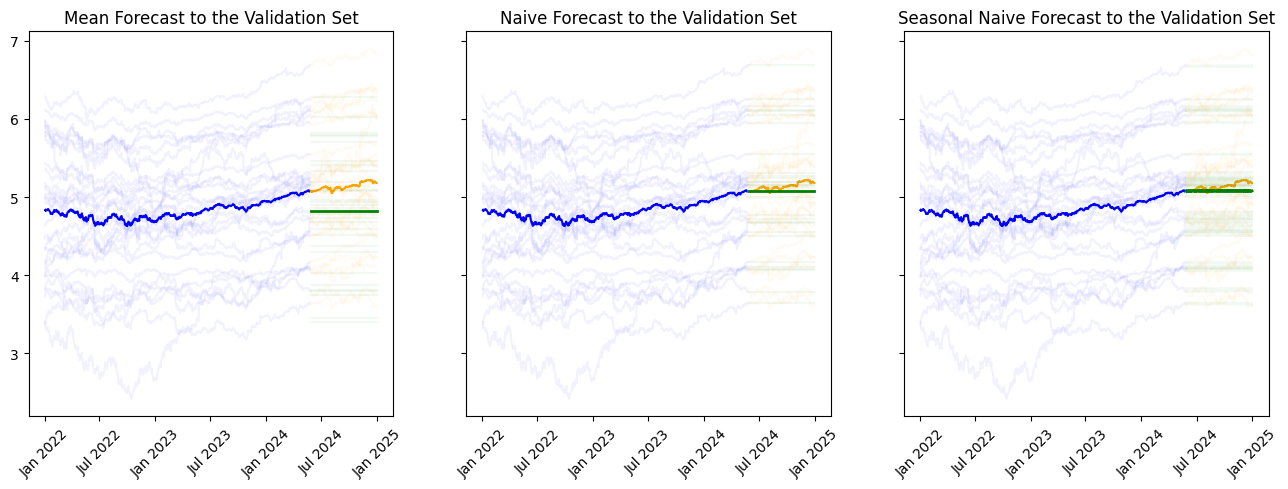

In [159]:
import matplotlib.dates as mdates
# Drawing time!
fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

opacity_num = 0.05
for ax in axs:
    ax.plot(train_df, color='blue', alpha=opacity_num)
    ax.plot(train_df.mean(axis=1), color='blue')

    ax.plot(val_df, color='orange', alpha=opacity_num)
    ax.plot(val_df.mean(axis=1), color='orange', label='Val Median')

# Plot the mean
axs[0].plot(mean_forecast, label='Mean Forecast', color='green', alpha=opacity_num)
axs[0].plot(mean_forecast.mean(axis=1), label='Mean Forecast', linewidth=2, color='green')
axs[0].set_title('Mean Forecast to the Validation Set')

# plot the naive
axs[1].plot(naive_forecast, label='Naive Forecast', color='green', alpha=opacity_num)
axs[1].plot(naive_forecast.mean(axis=1), label='Naive Forecast', linewidth=2, color='green')
axs[1].set_title('Naive Forecast to the Validation Set')

# plot the Seasonal Naive
axs[2].plot(seasonal_naive_forecast, label='Seasonal Naive Forecast', color='green', alpha=opacity_num)
axs[2].plot(seasonal_naive_forecast.mean(axis=1), label='Seasonal Naive Forecast', linewidth=2, color='green')
axs[2].set_title('Seasonal Naive Forecast to the Validation Set')

# Prettier x-axis
for ax in axs:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # major ticks each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # format as 'Jan 2025'
    ax.tick_params(axis='x', rotation=45)  # rotate labels


In [162]:
from utils import ForecastingMetrics

# Dictionary to store all metrics
performance_stock = {}

for stock in val_df.columns:
    # Compute metrics for each baseline
    performance_stock[stock] = {
        'Mean': ForecastingMetrics.compute_all_metrics(val_df[stock], mean_forecast[stock]),
        'Naive': ForecastingMetrics.compute_all_metrics(val_df[stock], naive_forecast[stock]),
        'Seasonal Naive': ForecastingMetrics.compute_all_metrics(val_df[stock], seasonal_naive_forecast[stock])
    }

# Convert to a DataFrame for readability
# We'll MultiIndex this to have stock -> baseline -> metric
df_list = []
for stock, metrics_dict in performance_stock.items():
    for baseline, metrics in metrics_dict.items():
        # metrics is assumed to be a dictionary {metric_name: value, ...}
        row = metrics.copy()
        row['Stock'] = stock
        row['Baseline'] = baseline
        df_list.append(row)

metrics_df = pd.DataFrame(df_list)
metrics_df = metrics_df.set_index(['Stock', 'Baseline'])

# Display
# This is the mean scores across the different stocks
metrics_df.groupby(level='Baseline').mean()

,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Baseline,,,,,,
Mean,0.321077,0.177515,0.331087,6.198289,6.564264,46.511112
Naive,0.089097,0.017392,0.108980,1.736799,1.762611,46.511112
Seasonal Naive,0.093134,0.018924,0.112645,1.819917,1.847516,51.088886


# ARIMA


# VAR